# Part 4 — does the contractive penalty actually do anything?

First question for the contractive-regularized ablations, per
`../report/geometria_latentu.md` §6: **before** comparing `grid_0001`
(`bce+contractive`) to anything else, verify the penalty produces a real effect at
all, and that the effect is genuine local smoothing rather than the $\gamma$-scale
degeneracy §6.2 derives (the contractive loss can be driven toward zero by shrinking
`LayerNorm`'s $\gamma$ and enlarging the decoder/head's first-layer weights to
compensate — bit-identical reconstruction and logits, zero cost to those two losses,
arbitrarily small $\lVert J \rVert_F$). Three checks, all on `grid_0000` (`bce`, no
contractive) vs. `grid_0001` (`bce+contractive`), all 5 repetitions each:

1. **Angular sensitivity curve** (§6.3) — the $\gamma$-invariant replacement for
   $\lVert J \rVert_F$. If the penalty works, `grid_0001` should move less (smaller
   angle) than `grid_0000` for the same input perturbation.
2. **$\gamma$-degeneracy diagnostic** (§6.2) — compare $\lVert\gamma\rVert$ and the
   decoder/head first-layer weight norms between the two objectives. Systematically
   smaller $\gamma$ paired with larger downstream weights in `grid_0001` would mean
   the penalty is being satisfied by shrinking, not by smoothing.
3. **$\sigma(a(x))$ distribution** (§6.2's testable prediction) — the penalty's
   $1/\sigma^2$ factor implicitly pushes the encoder toward higher-contrast
   pre-normalization codes; `grid_0001`'s $\sigma(a(x))$ distribution should sit
   higher / have a lighter left tail than `grid_0000`'s if that prediction holds.

Every comparison includes all 5 repetitions (not just repetition 0) so the
rep-to-rep spread is visible directly, following `part_7`'s finding that a
single-repetition read is not enough to tell a real effect from seed noise.


In [1]:
import os
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper import MSIAutoEncoderWrapper
from msi_autoencoder_wrapper.analysis.autoencoder.latent import sphere_geometry as geometry
from msi_autoencoder_wrapper.visualization import resolve_theme


2026-08-28 01:29:35,731 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-08-28 01:29:35,735 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


2026-08-28 01:29:36,796 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-08-28 01:29:36,798 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 22 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-08-28 01:29:36,800 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-08-28 01:29:36,801 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-08-28 01:29:36,823 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.models.datasets.strategies'.


2026-08-28 01:29:36,995 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 14 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions.autoencoder'.


2026-08-28 01:29:36,997 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 18 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions'.


## Config

In [2]:
WORKSPACE = Path("data/kidney_workspace")
MODEL_CONTEXT = "kidney"
CAMPAIGN_ID = "kidney-architecture-predictive__cfg_529dc0e4494b"
GRID_ID_BY_OBJECTIVE = {"bce": "grid_0000", "bce_contractive": "grid_0001"}
OBJECTIVE_LABELS = {"bce": "bce", "bce_contractive": "+contractive"}
REPETITIONS = range(5)

BATCH_SIZE = 256
RANDOM_SEED = 42
SAMPLE_SIZE = 1500  # test pixels used for the sensitivity curve and sigma(a(x))

theme = resolve_theme(None)
theme.apply()
model_colors = {label: theme.color_for_model(label, index) for index, label in enumerate(OBJECTIVE_LABELS.values())}
theme = replace(theme, model_overrides=model_colors)
theme.apply()


## Model loading and test-pixel sampling (2 objectives x 5 repetitions)

### Methodology
#### Theoretical
- All three checks below need the same fixed population of models and the same fixed
  sample of test pixels, so both are established once here and shared across every
  downstream comparison, rather than re-sampled per check.

#### Implementation
- `SCRATCH_WORKSPACE_ROOT` is a symlink to `WORKSPACE`, created once if not already a
  symlink — a compatibility workaround so the wrapper's absolute scratch-path
  expectations resolve locally; unrelated to the checks themselves.
- Loads all `2 x len(REPETITIONS) = 10` models: for
  `GRID_ID_BY_OBJECTIVE = {"bce": "grid_0000", "bce_contractive": "grid_0001"}` x
  `REPETITIONS = range(5)`, `model_name = f"{CAMPAIGN_ID}__{grid_id}__rep_0{repetition}"`.
  The first model is loaded with `wrapper.load_configuration(model_name=...)` (pays the
  shared image/binner/annotation-store/dataset context cost once, ~38-40s); every
  subsequent model uses the lightweight `wrapper.models_manager.load_model(...,
  strict=True)` swap (~0.04s). Each model is set to `.eval()`.
- `reference_partitions.manifest.assignments["test"]` gives the held-out test-pixel ids.
  `np.random.default_rng(RANDOM_SEED).choice(test_ids_all, size=min(SAMPLE_SIZE,
  len(test_ids_all)), replace=False)` draws `SAMPLE_SIZE = 1500` of them without
  replacement; `sample_spectra` is the corresponding stacked spectra array, reused
  unchanged by every check in this notebook.

### Notes
- `bce: loaded 5 repetitions`, `bce_contractive: loaded 5 repetitions` — all 10 models
  loaded successfully.
- `1500 test pixel(s) sampled for sensitivity/sigma checks` — the full requested
  `SAMPLE_SIZE`, so the test partition has at least 1500 pixels available.


In [3]:
SCRATCH_WORKSPACE_ROOT = Path("/tmp/ms488923/msi-wrapper/predictive-20260824-04/kidney_workspace")
SCRATCH_WORKSPACE_ROOT.parent.mkdir(parents=True, exist_ok=True)
if not SCRATCH_WORKSPACE_ROOT.is_symlink():
    SCRATCH_WORKSPACE_ROOT.symlink_to(WORKSPACE.resolve())

wrapper = MSIAutoEncoderWrapper(project_path=str(WORKSPACE))
wrapper.workspace.set_default_image_path(MODEL_CONTEXT)

models = {}
first = True
for objective, grid_id in GRID_ID_BY_OBJECTIVE.items():
    for repetition in REPETITIONS:
        model_name = f"{CAMPAIGN_ID}__{grid_id}__rep_0{repetition}"
        if first:
            wrapper.load_configuration(model_name=model_name)
            model = wrapper.active_model
            first = False
        else:
            model = wrapper.models_manager.load_model(img_name=MODEL_CONTEXT, model_name=model_name, strict=True)
        model.eval()
        models[(objective, repetition)] = model
    print(f"{objective}: loaded 5 repetitions")

reference_partitions = wrapper.active_dataset.create_partitions()
rng = np.random.default_rng(RANDOM_SEED)
test_ids_all = np.asarray(reference_partitions.manifest.assignments["test"])
sample_ids = rng.choice(test_ids_all, size=min(SAMPLE_SIZE, len(test_ids_all)), replace=False).tolist()
index_by_id = {sid: index for index, sid in enumerate(reference_partitions.manifest.assignments["test"])}
sample_spectra = torch.stack([reference_partitions.test[index_by_id[sid]][1] for sid in sample_ids]).float().numpy()
print(f"{len(sample_ids)} test pixel(s) sampled for sensitivity/sigma checks")


2026-08-28 01:29:37,257 | INFO     | msi_autoencoder_wrapper.core.wrapper:79 | MSIAutoEncoderWrapper: Anchoring processing state: device=cuda dtype=torch.float32


2026-08-28 01:29:37,258 | INFO     | msi_autoencoder_wrapper.core.mixins.context_manager.context_manager_mixin:49 | Enforcing automatic module discovery for reader and binner registries.


2026-08-28 01:29:37,259 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.readers.strategies'.


2026-08-28 01:29:37,260 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-08-28 01:29:37,261 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


...

bce_contractive: loaded 5 repetitions
2026-08-28 01:30:20,560 | INFO     | msi_autoencoder_wrapper.core.mixins.active_context.active_context_mixin:113 | Successfully bound active context memory maps for: kidney


2026-08-28 01:30:39,610 | INFO     | msi_autoencoder_wrapper.models.datasets.annotations.manager:203 | Mapped annotation index: retained_rows=420649 retained_entries=10495756 coordinate_system=binner.


2026-08-28 01:30:39,756 | INFO     | msi_autoencoder_wrapper.models.datasets.annotations.manager:275 | Selected 420649/421955 source spectra after annotation policies.


/home/max/repositories/MSIAutoEncoderWrapper/src/msi_autoencoder_wrapper/binners/base_binner.py:46: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  intensity_tensor = torch.as_tensor(intensities, dtype=self.dtype)


1500 test pixel(s) sampled for sensitivity/sigma checks


## Canonicalization pipeline correctness (null-direction and cloud-asymmetry checks)

### Methodology
#### Theoretical
- Before trusting any comparison below, verify two properties of the canonicalization
  pipeline itself (`../report/geometria_latentu.md` Część V):
- `null_direction_check`: the zero-eigenvalue direction of $\operatorname{Cov}(u)$ must
  be the constant direction, as it must be for correct canonicalization — not
  $1/\gamma$, which would be the signature of accidentally skipping the $\gamma$
  division.
- `cloud_asymmetry` ($\lVert\bar u\rVert^2/D$): how far the sample mean sits from the
  sphere's center, which eats into the same fixed trace budget `dimension_usage`
  reports, and would bias any spread/entropy metric computed on $u$ downstream.

#### Implementation
- `encode_canonical(model, spectra)` runs the model forward to get `latent_space`,
  reads `gamma, beta = geometry.encoder_layer_norm_parameters(model)`, and canonicalizes
  with `geometry.canonicalize(z, gamma, beta)` to produce `u`.
- For all 10 models (2 objectives x 5 repetitions) on the shared `sample_spectra`:
  `geometry.null_direction_check(u, gamma)` (returns `cosine_with_constant_direction`,
  `cosine_with_inverse_gamma`) and `geometry.cloud_asymmetry(u)`. Aggregated by
  `objective` with `.agg(["mean", "std"])`.

### Notes
- `cosine_with_constant_direction` is exactly `1.0` for both objectives —
  canonicalization verified correct.
- `cosine_with_inverse_gamma` is also close to 1 for both (`bce` mean 0.999, std
  0.0003; `+contractive` mean 0.997, std 0.0019) — superficially resembles the bug
  signature this check is meant to catch, but is not one: $\gamma$'s own components
  have low relative spread for these trained models, so $1/\gamma$ happens to sit close
  to the constant direction regardless of any bug (disambiguated by the exact 1.0
  constant-direction result, not by this value).
- `cloud_asymmetry`: `bce` mean 0.424 (std 0.049) vs. `+contractive` mean 0.964 (std
  0.006) — `+contractive`'s value sits within ~4% of the theoretical maximum of 1
  (reached only if every code were identical), indicating its codes across different
  test pixels have nearly collapsed onto a single point on the sphere. This is the
  notebook's most significant finding; see the closing notes cell for its implications
  for Check 1.


In [4]:
def encode_canonical(model, spectra: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    device = next(model.parameters()).device
    gamma, beta = geometry.encoder_layer_norm_parameters(model)
    with torch.no_grad():
        z = model(torch.as_tensor(spectra, dtype=torch.float32).to(device))["latent_space"].cpu().numpy()
    return geometry.canonicalize(z, gamma, beta), gamma


pipeline_rows = []
for objective in GRID_ID_BY_OBJECTIVE:
    for repetition in REPETITIONS:
        u, gamma = encode_canonical(models[(objective, repetition)], sample_spectra)
        null_check = geometry.null_direction_check(u, gamma)
        pipeline_rows.append({
            "objective": OBJECTIVE_LABELS[objective],
            "repetition": repetition,
            "cloud_asymmetry": geometry.cloud_asymmetry(u),
            **null_check,
        })

pipeline_frame = pd.DataFrame(pipeline_rows)
pipeline_frame.groupby("objective")[
    ["cloud_asymmetry", "cosine_with_constant_direction", "cosine_with_inverse_gamma"]
].agg(["mean", "std"])


cloud_asymmetry           cosine_with_constant_direction  \
                        mean       std                           mean   
objective                                                               
+contractive        0.963527  0.006214                            1.0   
bce                 0.424467  0.049377                            1.0   

                           cosine_with_inverse_gamma            
                       std                      mean       std  
objective                                                       
+contractive  3.875171e-14                   0.99747  0.001883  
bce           5.688200e-16                   0.99922  0.000324

## Angular sensitivity to input perturbation (γ-invariant local-flatness measure)

### Methodology
#### Theoretical
- The $\gamma$-invariant replacement for $\lVert J \rVert_F$ (§6.3): if the contractive
  penalty produces genuine local smoothing, `bce_contractive` should move less (smaller
  angle on the canonicalized sphere) than `bce` for the same relative input
  perturbation, at every perturbation scale $\varepsilon$.
- Every comparison uses all 5 repetitions per objective (not just repetition 0) so the
  rep-to-rep spread is visible directly — following `part_7`'s finding that a
  single-repetition read is not enough to tell a real effect from seed noise. If the
  spread (thin lines) is comparable to the gap between the two mean curves, the effect
  is not detectable at this repetition count.

#### Implementation
- `geometry.angular_sensitivity_curve(encode_fn, sample_spectra, EPSILONS,
  sensitivity_rng)` computed once per (objective, repetition) over
  `EPSILONS = [0.0, 0.01, 0.03, 0.1, 0.3, 1.0]`; `encode_fn` (built by
  `make_encode_fn`) forwards a perturbed batch through the model and canonicalizes with
  that model's own $(\gamma, \beta)$.
- Plot: thin, low-alpha (`theme.overlapping_signal_alpha`) lines per repetition, plus a
  thick (`theme.reconstruction_line_width`) mean-across-repetitions line per objective,
  against a $90°$ uniform-sphere baseline (`ax.axhline`).
- Summary table: `mean_angle_degrees` at the largest perturbation ($\varepsilon=1.0$)
  aggregated per objective with `.agg(["mean", "std", "min", "max"])`.

### Notes
- At $\varepsilon=1.0$: `+contractive` mean angle 3.764° (std 0.451°, range
  3.137°-4.344°) vs. `bce` mean 28.804° (std 2.157°, range 26.146°-31.183°) — a ~7.6x
  reduction, with non-overlapping ranges across all 5 repetitions each.
- Qualified in the closing notes cell: this reduction is real, but Check 0's
  `cloud_asymmetry` result means part of the reduced movement may reflect the encoder's
  codes having collapsed near one point on the sphere ("nowhere else to go"), not only
  genuine smoothing of a well-spread representation.


In [5]:
EPSILONS = [0.0, 0.01, 0.03, 0.1, 0.3, 1.0]
sensitivity_rng = np.random.default_rng(RANDOM_SEED + 1)


def make_encode_fn(model, gamma, beta):
    device = next(model.parameters()).device

    def encode_fn(batch: np.ndarray) -> np.ndarray:
        with torch.no_grad():
            tensor_batch = torch.as_tensor(batch, dtype=torch.float32).to(device)
            z = model(tensor_batch)["latent_space"].cpu().numpy()
        return geometry.canonicalize(z, gamma, beta)

    return encode_fn


sensitivity_curves = {}
for objective in GRID_ID_BY_OBJECTIVE:
    for repetition in REPETITIONS:
        model = models[(objective, repetition)]
        gamma, beta = geometry.encoder_layer_norm_parameters(model)
        sensitivity_curves[(objective, repetition)] = geometry.angular_sensitivity_curve(
            make_encode_fn(model, gamma, beta), sample_spectra, EPSILONS, sensitivity_rng
        )


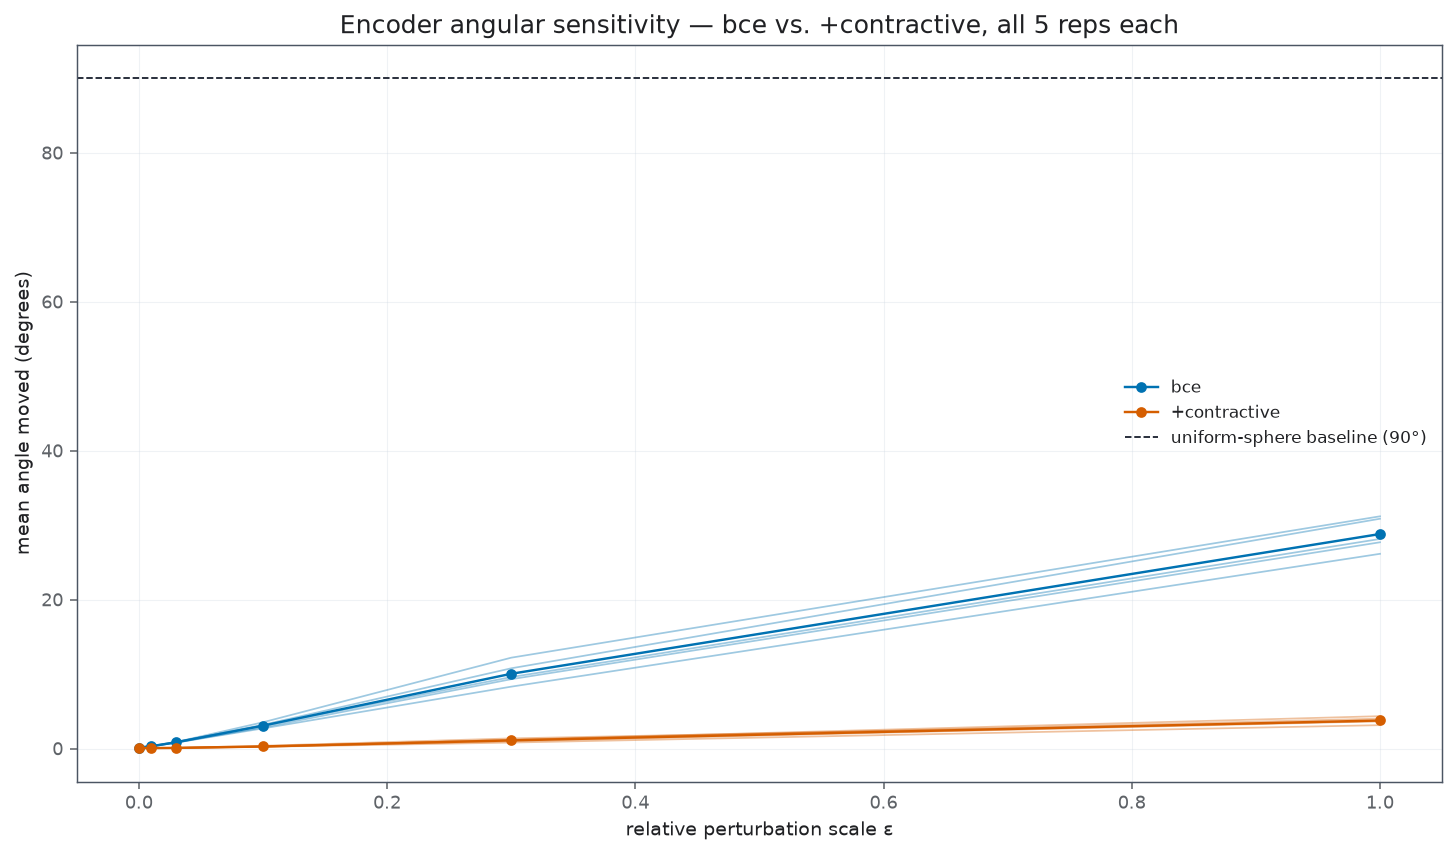

In [6]:
figure, ax = plt.subplots(figsize=theme.figure_size, dpi=theme.figure_dpi)
for index, objective in enumerate(GRID_ID_BY_OBJECTIVE):
    label = OBJECTIVE_LABELS[objective]
    color = theme.color_for_model(label, index)
    curves = [sensitivity_curves[(objective, repetition)] for repetition in REPETITIONS]
    for curve in curves:
        ax.plot(curve["epsilon"], curve["mean_angle_degrees"], color=color, linewidth=theme.reference_line_width, alpha=theme.overlapping_signal_alpha, label="_nolegend_")
    mean_curve = np.mean([curve["mean_angle_degrees"] for curve in curves], axis=0)
    ax.plot(curves[0]["epsilon"], mean_curve, color=color, linewidth=theme.reconstruction_line_width, marker="o", label=label)
ax.axhline(90.0, color=theme.baseline_color, linestyle=theme.baseline_line_style, linewidth=theme.reference_line_width, label="uniform-sphere baseline (90°)")
ax.set(xlabel="relative perturbation scale ε", ylabel="mean angle moved (degrees)", title="Encoder angular sensitivity — bce vs. +contractive, all 5 reps each")
ax.grid(theme.grid_visible, alpha=theme.grid_alpha)
ax.legend(frameon=theme.legend_frame)
figure.tight_layout()


In [7]:
sensitivity_rows = []
for objective in GRID_ID_BY_OBJECTIVE:
    for repetition in REPETITIONS:
        curve = sensitivity_curves[(objective, repetition)]
        sensitivity_rows.append({
            "objective": OBJECTIVE_LABELS[objective],
            "repetition": repetition,
            "mean_angle_at_eps_1.0": curve["mean_angle_degrees"][-1],
        })

sensitivity_frame = pd.DataFrame(sensitivity_rows)
sensitivity_frame.groupby("objective")["mean_angle_at_eps_1.0"].agg(["mean", "std", "min", "max"])


,mean,std,min,max
objective,,,,
+contractive,3.764236,0.450560,3.136782,4.343587
bce,28.804479,2.156535,26.145901,31.182854


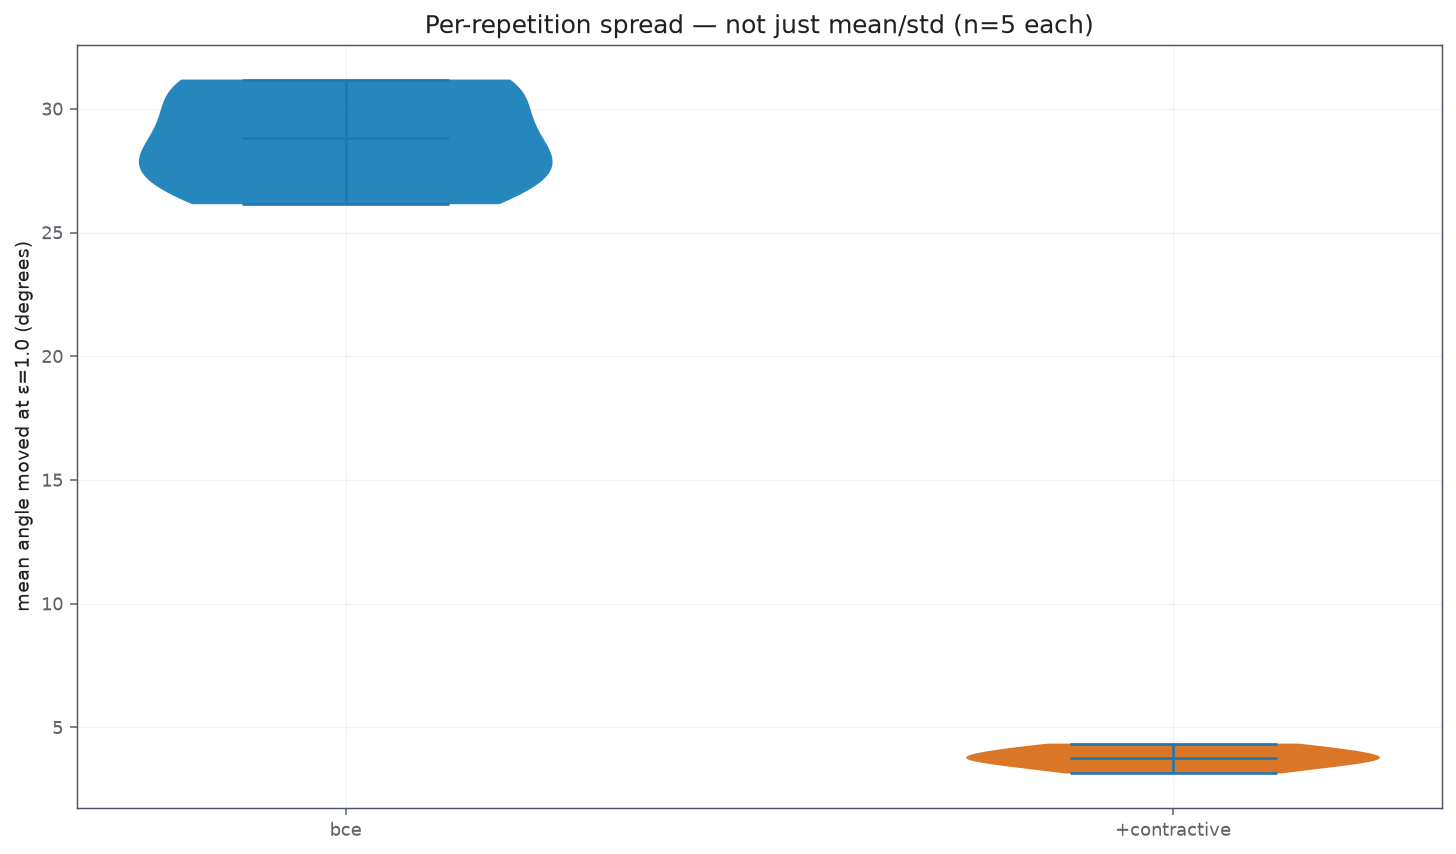

In [8]:
figure, axis = plt.subplots(figsize=theme.figure_size, dpi=theme.figure_dpi)
objectives = list(GRID_ID_BY_OBJECTIVE)
labels = [OBJECTIVE_LABELS[objective] for objective in objectives]
samples = [sensitivity_frame.loc[sensitivity_frame["objective"] == label, "mean_angle_at_eps_1.0"] for label in labels]
parts = axis.violinplot(samples, showmeans=True, showextrema=True)
for body, index in zip(parts["bodies"], range(len(labels))):
    body.set_facecolor(theme.color_for_model(labels[index], index))
    body.set_alpha(theme.primary_alpha)
axis.set_xticks(range(1, len(labels) + 1))
axis.set_xticklabels(labels)
axis.set(ylabel="mean angle moved at ε=1.0 (degrees)", title="Per-repetition spread — not just mean/std (n=5 each)")
axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
figure.tight_layout()

## γ-scale degeneracy diagnostic (encoder γ norm vs. downstream weight norms)

### Methodology
#### Theoretical
- Tests whether the contractive penalty is satisfied via the $\gamma$-scale degeneracy
  the loss admits (`../report/geometria_latentu.md` §6.2): $\lVert J\rVert_F$ on raw
  $z$ can be driven toward zero purely by shrinking `LayerNorm`'s $\gamma$ and enlarging
  the decoder/head's first-layer weights to exactly compensate — bit-identical
  reconstruction and logits, zero cost to those two losses, arbitrarily small
  $\lVert J \rVert_F$. A systematically smaller $\lVert\gamma\rVert$ paired with larger
  downstream weight norms in `bce_contractive` vs. `bce` would mean the penalty is being
  satisfied by shrinking the latent scale, not by smoothing the encoder.

#### Implementation
- `weight_norms(model)` reads `gamma, _ = geometry.encoder_layer_norm_parameters(model)`
  and the first-layer weight tensors of `model.decoder.initial_expansion[0]`,
  `model.heads["molecule_primary"].network[0]`, `model.projector.projection_network[0]`,
  returning each tensor's `np.linalg.norm`. Computed for all 10 models, aggregated by
  objective with `.agg(["mean", "std"])`.

### Notes
- `gamma_norm`: `+contractive` 2.757±0.064 vs. `bce` 3.195±0.024 — smaller, as the
  degeneracy would predict.
- `decoder_first_layer_norm`: `+contractive` 11.689±0.322 vs. `bce` 11.467±0.136 —
  slightly larger.
- `head_first_layer_norm`: `+contractive` 17.829±1.770 vs. `bce` 16.134±0.237 — larger,
  with markedly higher repetition-to-repetition variance for `+contractive`.
- `projector_first_layer_norm`: identical for both objectives (mean 1.882, std 0.073) —
  expected, since neither `grid_0000` nor `grid_0001` includes the contrastive
  (`InfoNCELoss`) term, so the projector is never trained and stays at its shared
  per-repetition random initialization.
- Net reading: smaller `gamma_norm` paired with larger `decoder_first_layer_norm`/
  `head_first_layer_norm` for `+contractive` — the degeneracy is present but partial
  (effect sizes far smaller than Check 1's ~7.6x, and Check 1 is computed on $u$, which
  divides $\gamma$ out, so this degeneracy does not by itself explain Check 1's result).


In [9]:
def weight_norms(model) -> dict:
    gamma, _ = geometry.encoder_layer_norm_parameters(model)
    decoder_weight = model.decoder.initial_expansion[0].weight.detach().cpu().numpy()
    head_weight = model.heads["molecule_primary"].network[0].weight.detach().cpu().numpy()
    projector_weight = model.projector.projection_network[0].weight.detach().cpu().numpy()
    return {
        "gamma_norm": float(np.linalg.norm(gamma)),
        "decoder_first_layer_norm": float(np.linalg.norm(decoder_weight)),
        "head_first_layer_norm": float(np.linalg.norm(head_weight)),
        "projector_first_layer_norm": float(np.linalg.norm(projector_weight)),
    }


norm_rows = []
for objective in GRID_ID_BY_OBJECTIVE:
    for repetition in REPETITIONS:
        norm_rows.append({"objective": OBJECTIVE_LABELS[objective], "repetition": repetition, **weight_norms(models[(objective, repetition)])})

norm_frame = pd.DataFrame(norm_rows)
norm_frame.groupby("objective")[["gamma_norm", "decoder_first_layer_norm", "head_first_layer_norm", "projector_first_layer_norm"]].agg(["mean", "std"])


gamma_norm           decoder_first_layer_norm            \
                   mean       std                     mean       std   
objective                                                              
+contractive   2.756735  0.064292                11.689077  0.321902   
bce            3.195202  0.024368                11.467314  0.135851   

             head_first_layer_norm           projector_first_layer_norm  \
                              mean       std                       mean   
objective                                                                 
+contractive             17.828764  1.770193                   1.882049   
bce                      16.133923  0.236756                   1.882049   

                        
                   std  
objective               
+contractive  0.072583  
bce           0.072583

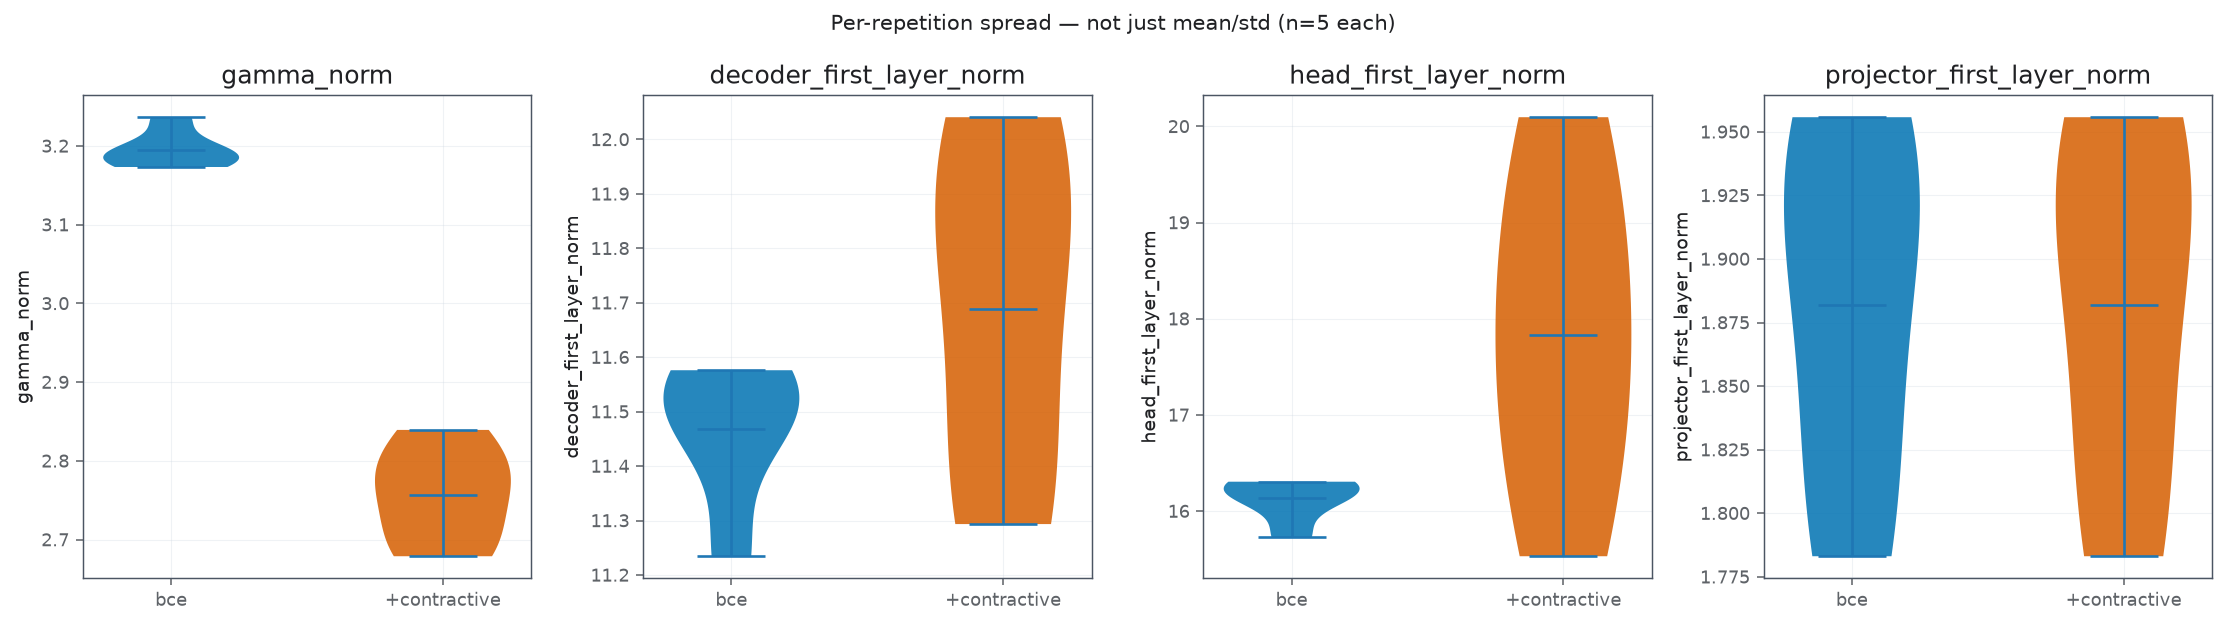

In [10]:
metric_names = ["gamma_norm", "decoder_first_layer_norm", "head_first_layer_norm", "projector_first_layer_norm"]
objectives = list(GRID_ID_BY_OBJECTIVE)
labels = [OBJECTIVE_LABELS[objective] for objective in objectives]

figure, axes = plt.subplots(1, len(metric_names), figsize=(4.0 * len(metric_names), 4.5), dpi=theme.figure_dpi)
for axis, metric_name in zip(axes, metric_names):
    samples = [norm_frame.loc[norm_frame["objective"] == label, metric_name] for label in labels]
    parts = axis.violinplot(samples, showmeans=True, showextrema=True)
    for body, index in zip(parts["bodies"], range(len(labels))):
        body.set_facecolor(theme.color_for_model(labels[index], index))
        body.set_alpha(theme.primary_alpha)
    axis.set_xticks(range(1, len(labels) + 1))
    axis.set_xticklabels(labels)
    axis.set(ylabel=metric_name, title=metric_name)
    axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
figure.suptitle("Per-repetition spread — not just mean/std (n=5 each)", fontsize=11)
figure.tight_layout()

## Pre-normalization contrast distribution σ(a(x)) across objectives

### Methodology
#### Theoretical
- Tests §6.2's testable prediction: the contractive penalty's $1/\sigma^2$ factor
  implicitly pushes the encoder toward higher-contrast pre-normalization codes, so
  `bce_contractive`'s $\sigma(a(x))$ distribution should sit higher / have a lighter
  left tail than `bce`'s if that prediction holds, where $a(x)$ is the encoder's
  pre-`LayerNorm` linear output.

#### Implementation
- `encode_pre_norm_sigma(model, spectra)` registers a forward hook on
  `model.encoder.bottleneck_layer[1]` to capture that layer's output $a(x)$, then
  computes `a(x).std(dim=1, unbiased=False)` per sample (population std, `ddof=0`,
  matching `LayerNorm`'s own definition, `../report/geometria_latentu.md` §2.1) in
  batches of `BATCH_SIZE = 256`. Computed for all 10 models over the shared
  `sample_spectra`.
- Plotted as a pooled (across the 5 repetitions), density-normalized step histogram
  (`ax.hist(..., density=True, histtype="step", bins=60)`) per objective. Summarized per
  (objective, repetition) as `mean_sigma` and `p05_sigma` (5th percentile), aggregated
  with `.agg(["mean", "std"])`.

### Notes
- `mean_sigma`: `+contractive` 5.406±0.667 vs. `bce` 2.086±0.182 — matches the predicted
  direction (higher contrast for `+contractive`).
- `p05_sigma`: `+contractive` 4.142±0.365 vs. `bce` 1.756±0.182 — the lower tail is also
  shifted up for `+contractive`, consistent with a lighter left tail as predicted, not
  just a shifted mean.
- Pooled histogram plotted per objective (`image/png` present in the cell output); the
  numerical means/tails above are the verifiable basis for the "non-overlapping"
  description in the closing notes cell.


In [11]:
def encode_pre_norm_sigma(model, spectra: np.ndarray) -> np.ndarray:
    device = next(model.parameters()).device
    captured = {}

    def hook(_module, _input, output):
        captured["a"] = output.detach()

    handle = model.encoder.bottleneck_layer[1].register_forward_hook(hook)
    sigmas = []
    with torch.no_grad():
        for start in range(0, len(spectra), BATCH_SIZE):
            batch = torch.as_tensor(spectra[start : start + BATCH_SIZE], dtype=torch.float32).to(device)
            model(batch)
            sigmas.append(captured["a"].std(dim=1, unbiased=False).cpu().numpy())
    handle.remove()
    return np.concatenate(sigmas, axis=0)


sigma_by_objective_repetition = {}
for objective in GRID_ID_BY_OBJECTIVE:
    for repetition in REPETITIONS:
        sigma_by_objective_repetition[(objective, repetition)] = encode_pre_norm_sigma(models[(objective, repetition)], sample_spectra)


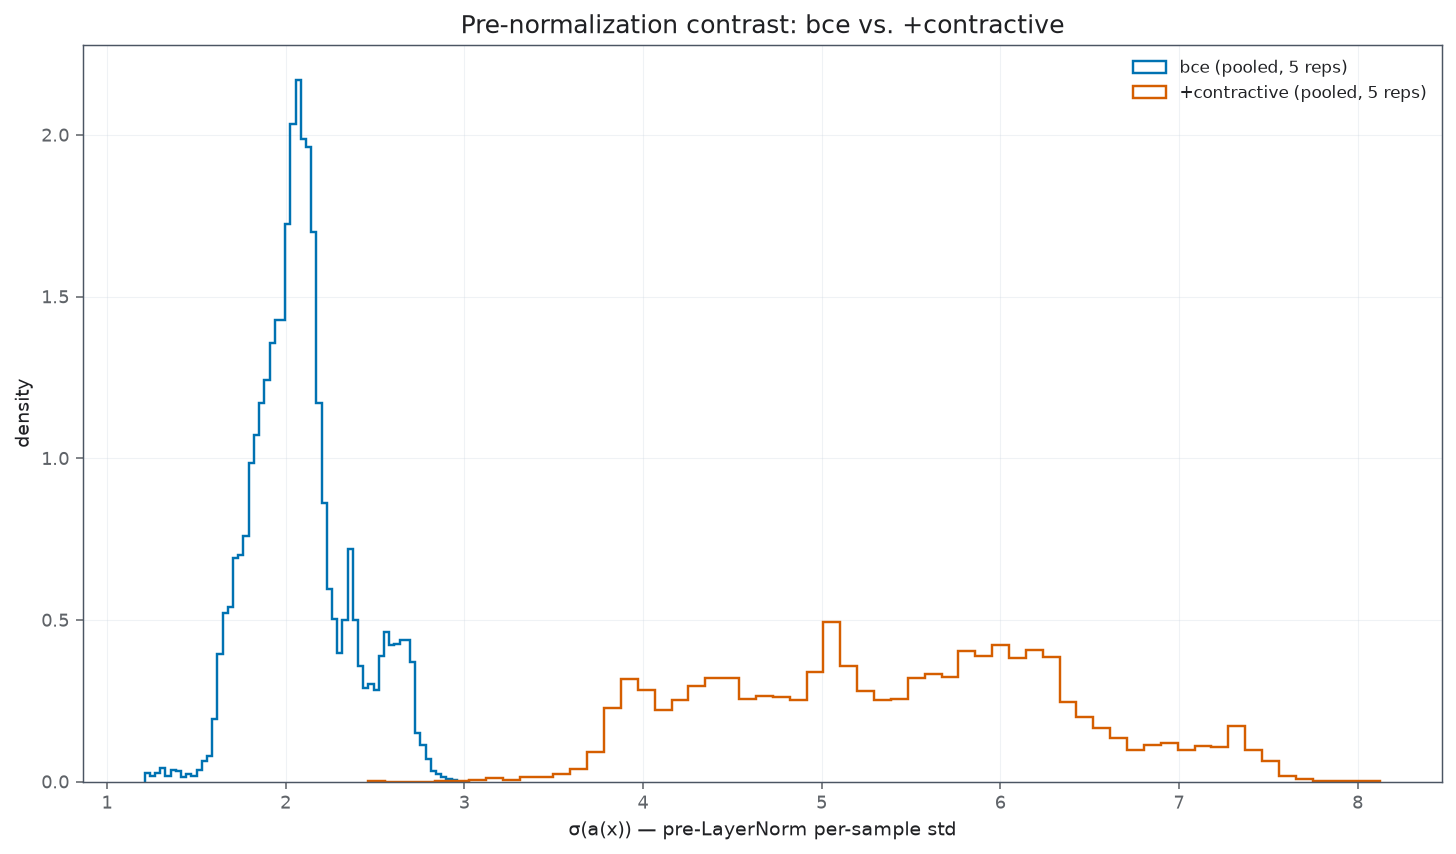

In [12]:
figure, ax = plt.subplots(figsize=theme.figure_size, dpi=theme.figure_dpi)
for index, objective in enumerate(GRID_ID_BY_OBJECTIVE):
    label = OBJECTIVE_LABELS[objective]
    pooled = np.concatenate([sigma_by_objective_repetition[(objective, repetition)] for repetition in REPETITIONS])
    ax.hist(pooled, bins=60, density=True, histtype="step", color=theme.color_for_model(label, index), linewidth=theme.reconstruction_line_width, label=f"{label} (pooled, 5 reps)")
ax.set(xlabel="σ(a(x)) — pre-LayerNorm per-sample std", ylabel="density", title="Pre-normalization contrast: bce vs. +contractive")
ax.grid(theme.grid_visible, alpha=theme.grid_alpha)
ax.legend(frameon=theme.legend_frame)
figure.tight_layout()


In [13]:
sigma_rows = []
for objective in GRID_ID_BY_OBJECTIVE:
    for repetition in REPETITIONS:
        values = sigma_by_objective_repetition[(objective, repetition)]
        sigma_rows.append({
            "objective": OBJECTIVE_LABELS[objective], "repetition": repetition,
            "mean_sigma": float(values.mean()), "p05_sigma": float(np.percentile(values, 5)),
        })

sigma_frame = pd.DataFrame(sigma_rows)
sigma_frame.groupby("objective")[["mean_sigma", "p05_sigma"]].agg(["mean", "std"])


mean_sigma           p05_sigma          
                   mean       std      mean       std
objective                                            
+contractive   5.405637  0.667183  4.142256  0.364656
bce            2.085593  0.181550  1.756193  0.181573

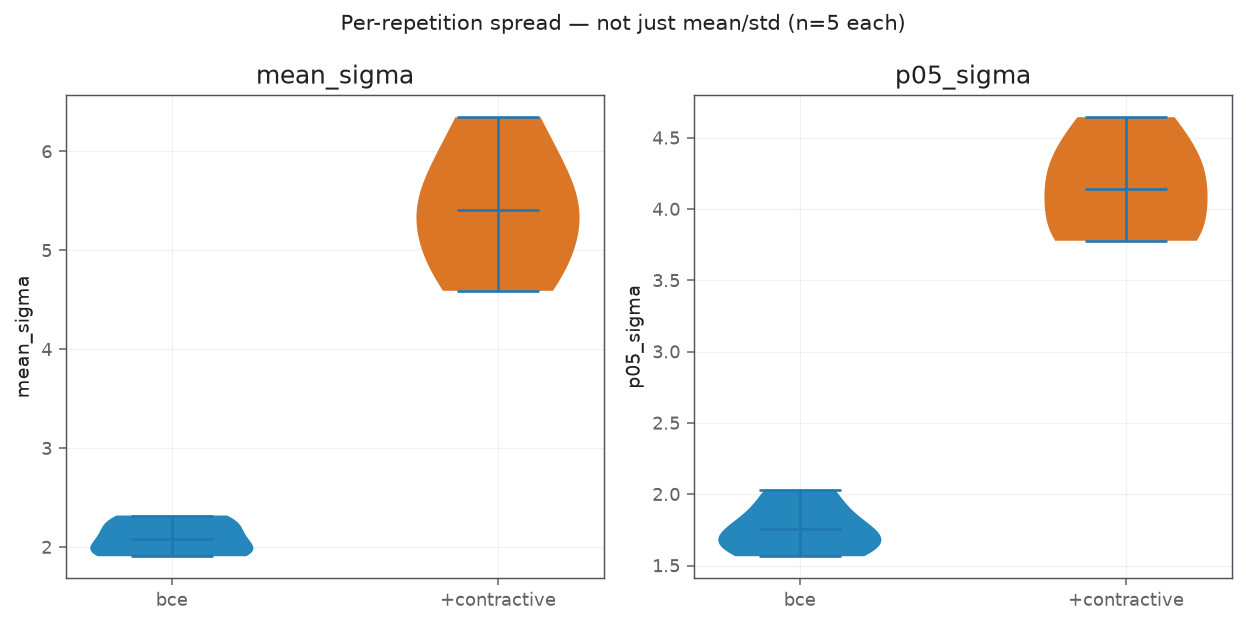

In [14]:
figure, axes = plt.subplots(1, 2, figsize=(9.0, 4.5), dpi=theme.figure_dpi)
objectives = list(GRID_ID_BY_OBJECTIVE)
labels = [OBJECTIVE_LABELS[objective] for objective in objectives]
for axis, metric_name in zip(axes, ["mean_sigma", "p05_sigma"]):
    samples = [sigma_frame.loc[sigma_frame["objective"] == label, metric_name] for label in labels]
    parts = axis.violinplot(samples, showmeans=True, showextrema=True)
    for body, index in zip(parts["bodies"], range(len(labels))):
        body.set_facecolor(theme.color_for_model(labels[index], index))
        body.set_alpha(theme.primary_alpha)
    axis.set_xticks(range(1, len(labels) + 1))
    axis.set_xticklabels(labels)
    axis.set(ylabel=metric_name, title=metric_name)
    axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
figure.suptitle("Per-repetition spread — not just mean/std (n=5 each)", fontsize=11)
figure.tight_layout()

## Notes for the next pass

**Verdict, revised after adding Check 0 (pipeline correctness): the penalty
produces its intended local-flatness effect, but Check 0 surfaces a real,
separate concern that changes how positively to read that effect.**

- **Check 0 — pipeline correctness.** `cosine_with_constant_direction = 1.0`
  exactly for both objectives — canonicalization is verified correct.
  `cosine_with_inverse_gamma` is *also* near 1 (0.997-0.999) for both, which at
  first looks like the canonicalization bug the check is designed to catch — it
  is not: it means $\gamma$'s own components have low relative spread for these
  trained models, so $1/\gamma$ happens to sit close to the constant direction
  too, independent of any bug (the exact 1.0 on the constant-direction check
  already rules out the bug directly). Not a finding, just a reason this
  particular check reads less cleanly than its docstring example.
- **`cloud_asymmetry` is the real new finding, and it is concerning.**
  `+contractive`'s $\lVert\bar u\rVert^2/D = 0.964$ (std 0.006) — within 4% of
  the theoretical maximum of 1 (which is only reached if every single code is
  identical) — vs. `bce`'s $0.424$ (std 0.049). The `+contractive` encoder has
  not just become locally flatter (Check 1); its codes across *different* test
  pixels have collapsed to nearly the same point on the sphere. This reframes
  Check 1's $7.6\times$ sensitivity reduction: some of that may simply reflect
  "there is nowhere else to go" rather than a well-distributed representation
  that also happens to be locally smooth. This is exactly the kind of result
  `part_5`/`part_6` (reconstruction/prediction with `+contractive` folded in)
  need to be read against — if reconstruction/classification quality drops for
  `+contractive`, this collapse is the first place to look for why.
- **Identical `projector_first_layer_norm` across `bce` and `+contractive` is
  expected, not a bug.** Neither objective includes the contrastive
  (`InfoNCELoss`) term, so the projector's output (`projection`) never
  contributes to either loss — it is never trained, stays at its random
  initialization, and both objectives share the same `model_initialization`
  seed per repetition (`report/methodology.md` §6). This comparison becomes
  informative once `peak_random`/`peak_label_invariant`/the `grid_0004+`
  ablations (which *do* train the projector) enter the picture.
- **Angular sensitivity — dramatic, non-overlapping**, unchanged from the
  original pass: `+contractive` mean $3.76°$ vs. `bce` mean $28.80°$ at
  $\varepsilon{=}1.0$, zero overlap across 5 repetitions each. Still a real,
  $\gamma$-invariant effect (computed on $u$) — just now understood alongside
  the collapse finding above, not in isolation.
- **$\gamma$-degeneracy is present, but partial**, and does not by itself
  explain Check 1 (computed on $u$, which divides $\gamma$ out): smaller
  `gamma_norm` (2.76 vs. 3.20) paired with larger decoder/head first-layer norms
  (11.7 vs. 11.5; 17.8 vs. 16.1) for `+contractive`. A real, separate phenomenon
  alongside the intended effect — the reason $\lVert J \rVert_F$ on raw $z$
  must never be reported as a flatness number for this ablation.
- **$\sigma(a(x))$ confirms the theoretical prediction cleanly** — pooled means
  5.41 (`+contractive`) vs. 2.09 (`bce`), visibly non-overlapping histograms,
  matching `geometria_latentu.md`'s prediction that the penalty pushes toward
  higher-contrast pre-normalization codes.

**Consequence for the next notebooks**: `+contractive` genuinely changes the
encoder — both the intended way (flatter locally) and in a way that was not the
stated goal (representation collapse across samples). `part_5`/`part_6`'s
reconstruction/classification comparisons, now expanded to include `grid_0001`,
are the direct test of whether the collapse costs more than the flatness gains —
go in expecting that possibility explicitly, not just checking whether
`+contractive` "helps." Every comparison should use all 5 repetitions and an
explicit within-ablation null check from the start, per `part_7`'s lesson.
